In [7]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LogisticRegression

In [9]:
df = pd.read_csv('data.csv')

df.columns = df.columns.str.lower().str.replace(' ', '_')

categorical_columns = list(df.dtypes[df.dtypes == 'object'].index)

for c in categorical_columns:
    df[c] = df[c].str.lower().str.replace(' ', '_')

df.totalcharges = pd.to_numeric(df.totalcharges, errors='coerce')
df.totalcharges = df.totalcharges.fillna(0)

df.churn = (df.churn == 'yes').astype(int)

In [10]:
df_full_train, df_test = train_test_split(df, test_size=0.2, random_state=1)
df_train, df_val = train_test_split(df_full_train, test_size=0.25, random_state=1)

df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

y_train = df_train.churn.values
y_val = df_val.churn.values
y_test = df_test.churn.values

del df_train['churn']
del df_val['churn']
del df_test['churn']

In [11]:
numerical = ['tenure', 'monthlycharges', 'totalcharges']

categorical = [
    'gender',
    'seniorcitizen',
    'partner',
    'dependents',
    'phoneservice',
    'multiplelines',
    'internetservice',
    'onlinesecurity',
    'onlinebackup',
    'deviceprotection',
    'techsupport',
    'streamingtv',
    'streamingmovies',
    'contract',
    'paperlessbilling',
    'paymentmethod',
]

In [12]:
dv = DictVectorizer(sparse=False)

train_dict = df_train[categorical + numerical].to_dict(orient='records')
X_train = dv.fit_transform(train_dict)

model = LogisticRegression(max_iter=5000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=5000)

In [13]:
val_dict = df_val[categorical + numerical].to_dict(orient='records')
X_val = dv.transform(val_dict)

y_pred = model.predict_proba(X_val)[:, 1]
churn_decision = (y_pred >= 0.5)
(y_val == churn_decision).mean()

np.float64(0.8034066713981547)

In [14]:
# now let's go through the evaluation process, and checking the accuracy of the model:
# Accuracy: the number of correct predictions devided by the number of all predictions.
print((y_val == churn_decision).sum())
print(len(y_val))
accuracy = (y_val == churn_decision).sum() / len(y_val)
accuracy 

1132
1409


np.float64(0.8034066713981547)

In [15]:
# one thing we can do to increase the accuracy, is to move the %50 threshold:
def check_accuracy(threshold):
    churn_decision = (y_pred >= threshold)
    return (y_val == churn_decision).mean()

In [16]:
maximum = 0.8034066713981547
perfect_threshold = 0.5
thresholds = np.linspace(0, 1, 101)
for threshold in thresholds:
    accuracy = check_accuracy(threshold)
    if accuracy >= maximum:
        maximum = accuracy
        perfect_threshold = threshold

print(maximum)
print(perfect_threshold)

0.8069552874378992
0.51


In [17]:
# instead of implementing the accuracy formula ourselves, we can use the built-in functions of scikit-learn.
from sklearn.metrics import accuracy_score
accuracy_score(y_val, y_pred >= 0.51)

0.8069552874378992

In [18]:
# the accuracy seems good at first glance, but there is a problem:
print(accuracy_score(y_val, y_pred >= 0.51))
print(accuracy_score(y_val, y_pred >= 1))
print(accuracy_score(y_val, y_pred >= 0.51) - accuracy_score(y_val, y_pred >= 1))

0.8069552874378992
0.7260468417317246
0.08090844570617461


In [19]:
# it seems that the difference between the perfect threshold of our model,
# and a model that always predicts the customer is not going to churn, is only 8 percent.
# so, accuracy does not always illustrate how good our model is.
# in general, when we have class imbalance, we can't really depend on accuracy for evaluation.

In [20]:
# to find a good metric for this situation, let's first take a look at our errors and correct decisions using the Confusion Table:
actual_positives = (y_val == 1)
actual_negatives = (y_val == 0)
predicted_positives = (y_pred >= 0.51)
predicted_negatives = (y_pred < 0.51)

In [21]:
true_positives = (actual_positives & predicted_positives).sum()
true_negatives = (actual_negatives & predicted_negatives).sum()
false_positives = (actual_negatives & predicted_positives).sum()
false_negatives = (actual_positives & predicted_negatives).sum()

In [22]:
print(f"Number Of True Positives: {true_positives}")
print(f"Number Of True Negatives: {true_negatives}")
print(f"Number Of False Positives: {false_positives}")
print(f"Number Of False Negatives: {false_negatives}")

Number Of True Positives: 210
Number Of True Negatives: 927
Number Of False Positives: 96
Number Of False Negatives: 176


In [23]:
confusion_matrix = np.array([[true_negatives, false_positives], 
                             [false_negatives, true_positives]])
confusion_matrix

array([[927,  96],
       [176, 210]])

In [24]:
# we can look at the percentage of each type of error and correct decision as well:
(confusion_matrix / confusion_matrix.sum()).round(2)

array([[0.66, 0.07],
       [0.12, 0.15]])

In [25]:
# Evaluation Metrics: Precision and Recall
precision = true_positives / (true_positives + false_positives)
precision

np.float64(0.6862745098039216)

In [26]:
recall = true_positives / (false_negatives + true_positives) 
recall

np.float64(0.5440414507772021)

In [27]:
# ROC curves (receiver operating characteristic curves):
# False Positive Rate (FPR): false positives / false positives + true negatives
# True Positive Rate (TPR = recall): True positives / True positives + false negatives
fpr = false_positives / (false_positives + true_negatives) # minimize this
tpr = true_positives / (true_positives + false_negatives) # maximize this

In [28]:
# now let's compute these values for all thresholds and then plot them:
thresholds = np.linspace(0, 1, 101)

scores = []

for threshold in thresholds:
    actual_positives = (y_val == 1)
    actual_negatives = (y_val == 0)

    predicted_positives = (y_pred >= threshold)
    predicted_negatives = (y_pred < threshold)

    true_positives = (actual_positives & predicted_positives).sum()
    true_negatives = (actual_negatives & predicted_negatives).sum()

    false_positives = (actual_negatives & predicted_positives).sum()
    false_negatives = (actual_positives & predicted_negatives).sum()

    scores.append((threshold, true_positives, false_positives, false_negatives, true_negatives))

scores

[(np.float64(0.0), np.int64(386), np.int64(1023), np.int64(0), np.int64(0)),
 (np.float64(0.01), np.int64(385), np.int64(895), np.int64(1), np.int64(128)),
 (np.float64(0.02), np.int64(383), np.int64(804), np.int64(3), np.int64(219)),
 (np.float64(0.03), np.int64(382), np.int64(750), np.int64(4), np.int64(273)),
 (np.float64(0.04), np.int64(382), np.int64(709), np.int64(4), np.int64(314)),
 (np.float64(0.05), np.int64(378), np.int64(678), np.int64(8), np.int64(345)),
 (np.float64(0.06), np.int64(377), np.int64(653), np.int64(9), np.int64(370)),
 (np.float64(0.07), np.int64(374), np.int64(623), np.int64(12), np.int64(400)),
 (np.float64(0.08), np.int64(371), np.int64(588), np.int64(15), np.int64(435)),
 (np.float64(0.09), np.int64(370), np.int64(558), np.int64(16), np.int64(465)),
 (np.float64(0.1), np.int64(366), np.int64(533), np.int64(20), np.int64(490)),
 (np.float64(0.11), np.int64(365), np.int64(511), np.int64(21), np.int64(512)),
 (np.float64(0.12), np.int64(361), np.int64(497), 

In [29]:
df_scores = pd.DataFrame(scores, columns=["threshold", "true_positives", "false_positives", "false_negatives", "true_negatives"])

In [30]:
df_scores

,threshold,true_positives,false_positives,false_negatives,true_negatives
0,0.00,386,1023,0,0
1,0.01,385,895,1,128
2,0.02,383,804,3,219
3,0.03,382,750,4,273
4,0.04,382,709,4,314
...,...,...,...,...,...
96,0.96,0,0,386,1023
97,0.97,0,0,386,1023
98,0.98,0,0,386,1023
99,0.99,0,0,386,1023


In [31]:
df_scores["fpr"] = df_scores.false_positives / (df_scores.false_positives + df_scores.true_negatives) # minimize this
df_scores["tpr"] = df_scores.true_positives / (df_scores.true_positives + df_scores.false_negatives) # maximize this
df_scores

,threshold,true_positives,false_positives,false_negatives,true_negatives,fpr,tpr
0,0.00,386,1023,0,0,1.000000,1.000000
1,0.01,385,895,1,128,0.874878,0.997409
2,0.02,383,804,3,219,0.785924,0.992228
3,0.03,382,750,4,273,0.733138,0.989637
4,0.04,382,709,4,314,0.693060,0.989637
...,...,...,...,...,...,...,...
96,0.96,0,0,386,1023,0.000000,0.000000
97,0.97,0,0,386,1023,0.000000,0.000000
98,0.98,0,0,386,1023,0.000000,0.000000
99,0.99,0,0,386,1023,0.000000,0.000000


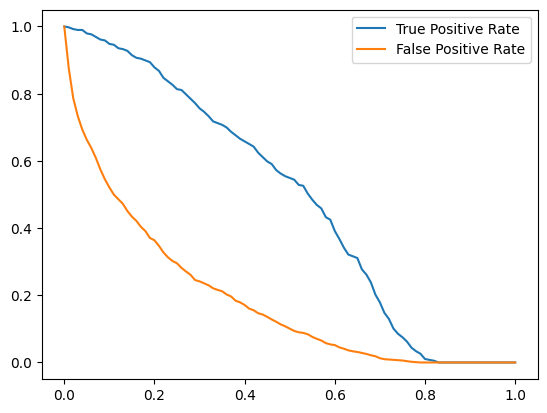

In [32]:
plt.plot(df_scores.threshold, df_scores.tpr, label="True Positive Rate")
plt.plot(df_scores.threshold, df_scores.fpr,label="False Positive Rate")
plt.legend()

In [33]:
# now, let's train a random model:
np.random.seed(1)
y_random = np.random.uniform(0, 1, size=len(y_val))
((y_random >= 0.5) == y_val).mean()

np.float64(0.5017743080198722)

In [34]:
# now, let's calculate fpr and tpr for our random model:
def tpr_fpr(y_val, y_pred):

    thresholds = np.linspace(0, 1, 101)

    scores = []

    for threshold in thresholds:
        actual_positives = (y_val == 1)
        actual_negatives = (y_val == 0)

        predicted_positives = (y_pred >= threshold)
        predicted_negatives = (y_pred < threshold)

        true_positives = (actual_positives & predicted_positives).sum()
        true_negatives = (actual_negatives & predicted_negatives).sum()

        false_positives = (actual_negatives & predicted_positives).sum()
        false_negatives = (actual_positives & predicted_negatives).sum()

        scores.append((threshold, true_positives, false_positives, false_negatives, true_negatives))

    df_scores = pd.DataFrame(scores, columns=["threshold", "true_positives", "false_positives", "false_negatives", "true_negatives"])
    df_scores["fpr"] = df_scores.false_positives / (df_scores.false_positives + df_scores.true_negatives)
    df_scores["tpr"] = df_scores.true_positives / (df_scores.true_positives + df_scores.false_negatives)

    return df_scores

In [35]:
df_random = tpr_fpr(y_val, y_random)

In [36]:
df_random

,threshold,true_positives,false_positives,false_negatives,true_negatives,fpr,tpr
0,0.00,386,1023,0,0,1.000000,1.000000
1,0.01,382,1013,4,10,0.990225,0.989637
2,0.02,379,993,7,30,0.970674,0.981865
3,0.03,375,979,11,44,0.956989,0.971503
4,0.04,372,969,14,54,0.947214,0.963731
...,...,...,...,...,...,...,...
96,0.96,14,41,372,982,0.040078,0.036269
97,0.97,11,36,375,987,0.035191,0.028497
98,0.98,8,19,378,1004,0.018573,0.020725
99,0.99,6,7,380,1016,0.006843,0.015544


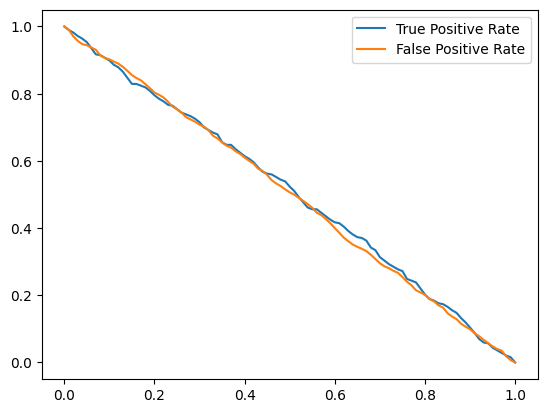

In [37]:
plt.plot(df_random.threshold, df_random.tpr, label="True Positive Rate")
plt.plot(df_random.threshold, df_random.fpr,label="False Positive Rate")
plt.legend()

In [38]:
# Ideal Model: a model that get's the prediction correct for all customers.
# this model usually doesen't exist in real life, but we will take a look at it.
number_of_negatives = (y_val == 0).sum()
number_of_positives = (y_val == 1).sum()
number_of_negatives, number_of_positives

(np.int64(1023), np.int64(386))

In [39]:
y_ideal = np.repeat([0, 1], [number_of_negatives, number_of_positives])
y_ideal

array([0, 0, 0, ..., 1, 1, 1], shape=(1409,))

In [40]:
y_ideal_prediction = np.linspace(0, 1, len(y_val))

In [41]:
accuracy = ((y_ideal_prediction >= 0.726) == y_ideal).mean()
accuracy

np.float64(1.0)

In [42]:
df_ideal = tpr_fpr(y_ideal, y_ideal_prediction)

In [43]:
df_ideal

,threshold,true_positives,false_positives,false_negatives,true_negatives,fpr,tpr
0,0.00,386,1023,0,0,1.000000,1.000000
1,0.01,386,1008,0,15,0.985337,1.000000
2,0.02,386,994,0,29,0.971652,1.000000
3,0.03,386,980,0,43,0.957967,1.000000
4,0.04,386,966,0,57,0.944282,1.000000
...,...,...,...,...,...,...,...
96,0.96,57,0,329,1023,0.000000,0.147668
97,0.97,43,0,343,1023,0.000000,0.111399
98,0.98,29,0,357,1023,0.000000,0.075130
99,0.99,15,0,371,1023,0.000000,0.038860


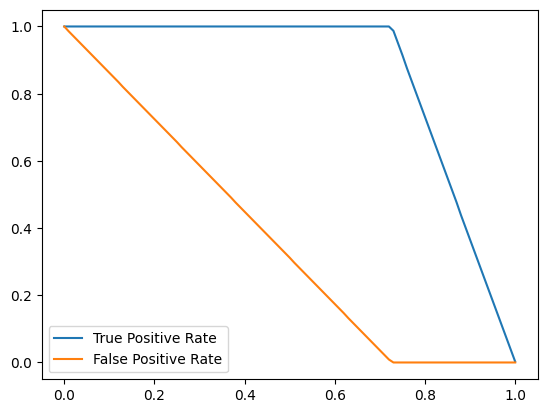

In [44]:
plt.plot(df_ideal.threshold, df_ideal.tpr, label="True Positive Rate")
plt.plot(df_ideal.threshold, df_ideal.fpr,label="False Positive Rate")
plt.legend()

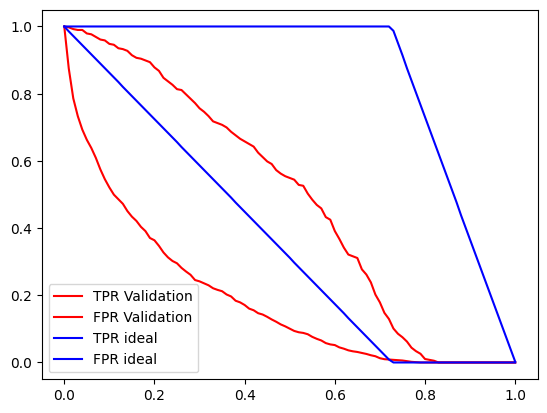

In [45]:
# now, let's put everything together:

plt.plot(df_scores.threshold, df_scores.tpr, label="TPR Validation", color="red")
plt.plot(df_scores.threshold, df_scores.fpr,label="FPR Validation", color="red")

# plt.plot(df_random.threshold, df_random.tpr, label="True Positive Rate")
# plt.plot(df_random.threshold, df_random.fpr,label="False Positive Rate")

plt.plot(df_ideal.threshold, df_ideal.tpr, label="TPR ideal", color="blue")
plt.plot(df_ideal.threshold, df_ideal.fpr,label="FPR ideal", color="blue")

plt.legend()

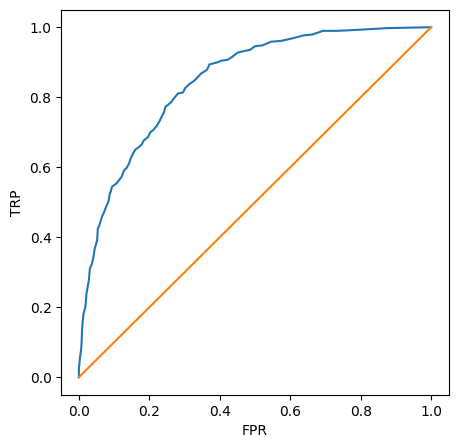

In [46]:
# another thing we can do is plotting false positive rate against true positive rate:

plt.figure(figsize=(5, 5))

plt.xlabel("FPR")
plt.ylabel("TRP")

plt.plot(df_scores.fpr, df_scores.tpr)
# plt.plot(df_random.fpr, df_random.tpr)
plt.plot([0, 1], [0, 1])
# plt.plot(df_ideal.fpr, df_ideal.tpr)

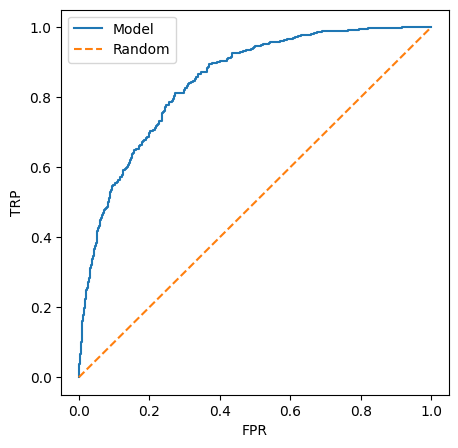

In [47]:
# all this process of plotting the roc curve can be done using built-in functions of scikit-learn:
from sklearn.metrics import roc_curve
fpr, tpr, thresholds = roc_curve(y_val, y_pred)

plt.figure(figsize=(5, 5))
plt.plot(fpr, tpr, label="Model")
plt.plot([0, 1], [0, 1], label="Random", linestyle="--")
plt.xlabel("FPR")
plt.ylabel("TRP")

plt.legend()

In [48]:
# calculating AOC (area under curve):
# the area under curve would be 1 for the ideal model and 0.5 for the random model.
# so, the area under curve should be always between 0.5 and 1.
# we can use the built-in functions of the scikit-learn library to calculate the area under curve:
from sklearn.metrics import auc
auc(fpr, tpr) # evaluated using all thresholds.

np.float64(0.8463626740410962)

In [49]:
auc(df_scores.fpr, df_scores.tpr) # evaluated using 101 thresholds.

np.float64(0.8461195609783274)

In [50]:
auc(df_ideal.fpr, df_ideal.tpr) # nearly 1, the accuracy issue is related to the thresholds.

np.float64(0.9999430203759136)

In [51]:
# we can also calculate the roc curve and its area all in one using scikit-learn methods:
from sklearn.metrics import roc_auc_score
roc_auc_score(y_val, y_pred)

np.float64(0.8463626740410962)

In [52]:
# the area under the curve (AOC) can be interpreted as:
# the probability that a randomly selected positive example has a higher score than a randomly selected negative example.
negative = y_pred[y_val == 0]
positive = y_pred[y_val == 1]

In [53]:
import random

n = 10000
success = 0
for i in range(n):
    negative_index = random.randint(0, len(negative) - 1)
    positive_index = random.randint(0, len(positive) - 1)
    if positive[positive_index] > negative[negative_index]:
        success += 1

success / n # this is very close to the area under the curve.

0.8474

In [54]:
pos_len = len(positive)
neg_len = len(negative) 
success = 0
for i in range(pos_len):
    for j in range(neg_len):
        negative_index = j
        positive_index = i
        if positive[positive_index] > negative[negative_index]:
            success += 1

success / (pos_len * neg_len) # this is exactly the same as the area under the curve.

0.8463626740410962

In [55]:
# Parameter tuning: 
# the process of selecting the best parameter for our model.
# we usually try to find the best parameter, on the validation set. however, this is not the only way.
# another method is to use the K-fold cross validation.
# in this method, we devide the train + validation dataset and devide it into K parts.
# then, for each of the K parts, we train our model on the rest of the parts, and then test on the Kth part.
# for each validation, we calculate the AUC and at the end, we can use AUC mean and std to see how stable our model is.

In [56]:
def train(df_train, y_train):
    dicts = df_train[categorical + numerical].to_dict(orient="records")

    dv = DictVectorizer(sparse=False)
    X_train = dv.fit_transform(dicts)

    model = LogisticRegression(max_iter=5000)
    model.fit(X_train, y_train)

    return dv, model

In [59]:
dv, model = train(df_train, y_train)

In [62]:
def predict(df_val, dv, model):
    dicts = df_val[categorical + numerical].to_dict(orient="records")

    X = dv.transform(dicts)
    y_pred = model.predict_proba(X)[:, 1]

    return y_pred

In [63]:
y_pred = predict(df_val, dv, model)

In [64]:
# there are built-in functions implemented for the K-fold cross validation method in the scikit-learn library:
from sklearn.model_selection import KFold

In [65]:
kfold = KFold(n_splits=10, shuffle=True, random_state=1)

In [72]:
scores = []

for train_index, val_index in kfold.split(df_full_train):
    df_train = df_full_train.iloc[train_index]
    df_val = df_full_train.iloc[val_index]

    y_train = df_train.churn.values
    y_val = df_val.churn.values

    dv, model = train(df_train, y_train)
    y_pred = predict(df_val, dv, model)

    auc = roc_auc_score(y_val, y_pred)
    scores.append(auc)

In [73]:
scores

[np.float64(0.8496413975160219),
 np.float64(0.8423886138613863),
 np.float64(0.8584289819444214),
 np.float64(0.8331577647930212),
 np.float64(0.824643300248139),
 np.float64(0.841092241092241),
 np.float64(0.8431943992184956),
 np.float64(0.8252767235926628),
 np.float64(0.8459315251222767),
 np.float64(0.8609794628751974)]

In [77]:
np.mean(scores), np.std(scores)

(np.float64(0.8424734410263863), np.float64(0.011675819459380274))

In [ ]:
# as in linear regression that we had the parameter landa, 
# here we have the parameter C for our logistic regression model.
# however, when C is small, it means the regularization is huge, and vice versa, which is the opposite of what landa did.

def train(df_train, y_train, C=1.0):
    dicts = df_train[categorical + numerical].to_dict(orient="records")

    dv = DictVectorizer(sparse=False)
    X_train = dv.fit_transform(dicts)

    model = LogisticRegression(max_iter=5000, C=C)
    model.fit(X_train, y_train)

    return dv, model

In [85]:
for C in [0.0001, 0.001, 0.01, 0.1, 0.5, 1, 10, 100, 1000, 10000, 100000]:
    scores = []

    for train_index, val_index in kfold.split(df_full_train):
        df_train = df_full_train.iloc[train_index]
        df_val = df_full_train.iloc[val_index]

        y_train = df_train.churn.values
        y_val = df_val.churn.values

        dv, model = train(df_train, y_train, C=C)
        y_pred = predict(df_val, dv, model)

        auc = roc_auc_score(y_val, y_pred)
        scores.append(auc)

    print(f"C = {C} ==> mean: {np.mean(scores)}, standard deviation: {np.std(scores)}")

C = 0.0001 ==> mean: 0.8110038196474371, standard deviation: 0.011866276830867616
C = 0.001 ==> mean: 0.8261100173135114, standard deviation: 0.011827193220505058
C = 0.01 ==> mean: 0.8408160241775123, standard deviation: 0.011817221464446328
C = 0.1 ==> mean: 0.8424097322949052, standard deviation: 0.01170442263332524
C = 0.5 ==> mean: 0.8425880373990736, standard deviation: 0.01167792301313584
C = 1 ==> mean: 0.8424734410263863, standard deviation: 0.011675819459380274
C = 10 ==> mean: 0.8423376012942049, standard deviation: 0.011578712687344594
C = 100 ==> mean: 0.8422088965644399, standard deviation: 0.01156534914372514
C = 1000 ==> mean: 0.8422708023807186, standard deviation: 0.01151754563232101
C = 10000 ==> mean: 0.8422474212308746, standard deviation: 0.011545056034373667
C = 100000 ==> mean: 0.8422195487199338, standard deviation: 0.011539712073905492


In [86]:
dv, model = train(df_full_train, df_full_train.churn, C=0.5)
y_pred = predict(df_test, dv, model)

auc = roc_auc_score(y_test, y_pred)
auc

np.float64(0.8584384174547974)